# Análisis offline de Theta/Beta y ERD durante imaginación motora — A18

Este notebook documenta y ejecuta de principio a fin el análisis offline desarrollado en `offline_mi_theta_beta_erd.py`. Su objetivo es comparar una ventana basal con una ventana de imaginación motora para un único sujeto del dataset empleado anteriormente en la clasificación LEFT/RIGHT.

El análisis responde cuatro preguntas:

1. ¿La razón **Theta/Beta** cambia entre baseline y MI?
2. ¿Cuál es el cambio porcentual en cada trial?
3. ¿Aparece **ERD en μ (8–13 Hz)**?
4. ¿Aparece **ERD en β (13–30 Hz)**?

> Este notebook está guardado con sus salidas. Los resultados pueden revisarse sin volver a ejecutar los archivos GDF.

## 1. Alcance y limitación experimental

El sujeto seleccionado es **A18**, porque anteriormente obtuvo el mejor resultado entre los modelos individuales CSP+PSD+LDA. Se utilizan sus seis sesiones completas: dos sesiones de adquisición y cuatro sesiones `onlineT`.

Este es un dataset de **imaginación motora**, no un dataset de neurofeedback atencional. Los participantes intentaban imaginar LEFT o RIGHT; no intentaban controlar Theta/Beta ni recibían instrucciones para modular atención. Por ello, este análisis valida la metodología espectral y explora cambios incidentales, pero **no valida todavía un índice de atención**.

## 2. Definición temporal

Los tiempos del ejemplo original —baseline 1–4 s y MI 5–9 s— no coinciden con los eventos reales de este dataset. Aquí se toma el evento `769` (LEFT) o `770` (RIGHT) como `t = 0`:

```text
Inicio trial       Fijación       Cue                 Fin aproximado
    −3 s              −1 s         0 s                       +5 s

Baseline: [−3, −1) s
MI:       [+1, +4) s
```

La ventana MI descarta el primer segundo posterior al cue y permanece dentro del trial. Esta adaptación evita mezclar fases o leer fuera del ensayo.

## 3. Importaciones y configuración

Las bandas, canales, ventanas y criterios quedan definidos explícitamente para que el análisis sea reproducible. Los GDF se leen desde `BCI_Exploration`; no se modifican.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
%matplotlib inline
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch
from scipy.stats import wilcoxon

# Encontrar el workspace aunque el notebook se abra desde diferentes carpetas.
current = Path.cwd().resolve()
candidates = [current, current.parent, *current.parents]
WORKSPACE_ROOT = next(
    path for path in candidates
    if (path / "BCI_Exploration").exists() and (path / "BCI_Neurofeedback").exists()
)
DATASET_ROOT = WORKSPACE_ROOT / "BCI_Exploration" / "BCI Database" / "Signals" / "DATA A"
OUTPUT_ROOT = WORKSPACE_ROOT / "BCI_Neurofeedback" / "results"
SUBJECT = "A18"

CHANNELS = ("C3", "Cz", "C4")
CLASS_EVENTS = {"769": "LEFT", "770": "RIGHT"}
BASELINE_SECONDS = (-3.0, -1.0)
MI_SECONDS = (1.0, 4.0)
LINE_FREQUENCY_HZ = 50.0
FILTER_BAND_HZ = (1.0, 40.0)
ARTIFACT_THRESHOLD_UV = 150.0
BANDS = {
    "theta": (4.0, 8.0),
    "mu": (8.0, 13.0),
    "beta": (13.0, 30.0),
}
EPSILON = np.finfo(float).eps

print("Workspace:", WORKSPACE_ROOT)
print("Sujeto:", SUBJECT)
print("Canales:", CHANNELS)
print("Baseline:", BASELINE_SECONDS, "s respecto al cue")
print("MI:", MI_SECONDS, "s respecto al cue")

Workspace: D:\Proyects\Python\BCI_workspace
Sujeto: A18
Canales: ('C3', 'Cz', 'C4')
Baseline: (-3.0, -1.0) s respecto al cue
MI: (1.0, 4.0) s respecto al cue


## 4. Comprobar los registros disponibles

A18 debe tener seis archivos GDF. Cada registro conserva la señal continua y las anotaciones necesarias para recuperar tanto el baseline como MI. No usamos `all_epochs_clean-epo.fif` porque ese archivo contiene únicamente 0.5–3.5 s después del cue y ya fue filtrado a 8–30 Hz, perdiendo baseline y gran parte de theta.

In [2]:
subject_dir = DATASET_ROOT / SUBJECT
gdf_files = sorted(subject_dir.glob("*.gdf"))

if not gdf_files:
    raise FileNotFoundError(f"No se encontraron GDF en {subject_dir}")

pd.DataFrame({
    "archivo": [path.name for path in gdf_files],
    "tamaño_MB": [round(path.stat().st_size / 1024**2, 2) for path in gdf_files],
})

,archivo,tamaño_MB
0,A18_R1_acquisition.gdf,56.27
1,A18_R2_acquisition.gdf,56.27
2,A18_R3_onlineT.gdf,56.27
3,A18_R4_onlineT.gdf,56.27
4,A18_R5_onlineT.gdf,56.27
5,A18_R6_onlineT.gdf,56.27


## 5. Estimación de potencia mediante Welch

Para cada ventana se estima la densidad espectral de potencia (PSD) con Welch:

- ventana Hann;
- segmentos de 1 segundo (`512` muestras);
- solapamiento interno del 50 %;
- detrend constante;
- unidades de PSD en V²/Hz.

Después se integra la PSD dentro de cada banda. La razón Theta/Beta no se obtiene de amplitudes instantáneas, sino de las potencias espectrales integradas.

In [3]:
def band_power(frequencies: np.ndarray, psd: np.ndarray, limits: tuple[float, float]) -> np.ndarray:
    """Integra la PSD para cada canal dentro de [fmin, fmax)."""
    fmin, fmax = limits
    mask = (frequencies >= fmin) & (frequencies < fmax)
    if mask.sum() < 2:
        raise ValueError(f"No hay suficientes bins para integrar {fmin}-{fmax} Hz.")
    return np.trapezoid(psd[:, mask], frequencies[mask], axis=1)

def spectral_powers(window_volts: np.ndarray, sampling_rate: float) -> dict[str, np.ndarray]:
    """Welch comparable entre ventanas usando segmentos fijos de un segundo."""
    segment_samples = int(round(sampling_rate))
    frequencies, psd = welch(
        window_volts,
        fs=sampling_rate,
        window="hann",
        nperseg=segment_samples,
        noverlap=segment_samples // 2,
        detrend="constant",
        scaling="density",
        axis=-1,
    )
    return {name: band_power(frequencies, psd, limits) for name, limits in BANDS.items()}

## 6. Preprocesamiento de cada sesión

La cadena aplicada a la señal continua es:

```text
GDF → tipos EEG/EOG/EMG → Notch 50 Hz → band-pass 1–40 Hz
    → referencia promedio EEG → selección C3, Cz y C4
```

Se usa Notch de 50 Hz porque el dataset fue registrado en Francia. El band-pass 1–40 Hz conserva theta, μ y beta. EOG y EMG se tipifican antes de calcular la referencia para que no entren en el promedio EEG.

In [4]:
def prepare_raw(path: Path) -> mne.io.BaseRaw:
    raw = mne.io.read_raw_gdf(path, preload=True, verbose="ERROR")
    typed_channels = {
        name: "eog" for name in ("EOG1", "EOG2", "EOG3") if name in raw.ch_names
    }
    typed_channels.update({
        name: "emg" for name in ("EMGg", "EMGd") if name in raw.ch_names
    })
    if typed_channels:
        raw.set_channel_types(typed_channels, verbose="ERROR")
    missing = sorted(set(CHANNELS) - set(raw.ch_names))
    if missing:
        raise RuntimeError(f"{path.name} no contiene los canales {missing}.")

    # El registro proviene de Francia: se elimina red a 50 Hz antes del low-pass.
    raw.notch_filter(
        freqs=[LINE_FREQUENCY_HZ], picks="eeg", method="iir",
        verbose="ERROR",
    )
    raw.filter(
        FILTER_BAND_HZ[0], FILTER_BAND_HZ[1], picks="eeg", method="iir",
        iir_params={"order": 4, "ftype": "butter"}, verbose="ERROR",
    )
    # Referencia promedio usando EEG; EOG y EMG fueron excluidos mediante sus tipos.
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    return raw

## 7. Extraer baseline y MI trial por trial

Para cada cue LEFT/RIGHT se extraen exactamente dos fragmentos de la misma sesión. Se calcula el pico absoluto y se marca como artefactado el trial que supere ±150 µV en cualquiera de los tres canales.

Se generan dos niveles de resultados:

- **Por canal:** C3, Cz y C4 permanecen separados.
- **Por trial:** primero se promedian las potencias de los tres canales y después se calcula el cociente. No se promedian razones con denominadores distintos.

Las fórmulas son:

```text
Theta/Beta = P_theta / P_beta
Cambio T/B (%) = 100 × (T/B_MI − T/B_baseline) / T/B_baseline
ERD (%) = 100 × (P_baseline − P_MI) / P_baseline
```

Con esta convención, ERD positivo significa reducción de potencia durante MI; ERD negativo representa aumento o ERS.

In [5]:
def extract_subject_trials(subject_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    files = sorted(subject_dir.glob("*.gdf"))
    if not files:
        raise FileNotFoundError(f"No se encontraron GDF en {subject_dir}.")

    channel_rows: list[dict] = []
    trial_rows: list[dict] = []
    rejected = 0
    discovered = 0

    for path in files:
        print(f"Procesando {path.name}...")
        raw = prepare_raw(path)
        sampling_rate = float(raw.info["sfreq"])
        events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
        descriptions = {code: description for description, code in event_id.items()}
        trial_number = 0

        for cue_sample, _, code in events:
            description = descriptions.get(int(code))
            if description not in CLASS_EVENTS:
                continue
            trial_number += 1
            discovered += 1
            class_name = CLASS_EVENTS[description]

            baseline_start = cue_sample + int(round(BASELINE_SECONDS[0] * sampling_rate))
            baseline_stop = cue_sample + int(round(BASELINE_SECONDS[1] * sampling_rate))
            mi_start = cue_sample + int(round(MI_SECONDS[0] * sampling_rate))
            mi_stop = cue_sample + int(round(MI_SECONDS[1] * sampling_rate))
            if baseline_start < 0 or mi_stop > raw.n_times:
                rejected += 1
                continue

            baseline = raw.get_data(
                picks=list(CHANNELS), start=baseline_start, stop=baseline_stop
            )
            mi = raw.get_data(picks=list(CHANNELS), start=mi_start, stop=mi_stop)
            peak_uv = float(max(np.abs(baseline).max(), np.abs(mi).max()) * 1e6)
            artifact = peak_uv > ARTIFACT_THRESHOLD_UV

            baseline_power = spectral_powers(baseline, sampling_rate)
            mi_power = spectral_powers(mi, sampling_rate)
            session = path.stem

            for channel_index, channel in enumerate(CHANNELS):
                theta_baseline = baseline_power["theta"][channel_index]
                theta_mi = mi_power["theta"][channel_index]
                beta_baseline = baseline_power["beta"][channel_index]
                beta_mi = mi_power["beta"][channel_index]
                mu_baseline = baseline_power["mu"][channel_index]
                mu_mi = mi_power["mu"][channel_index]
                ratio_baseline = theta_baseline / max(beta_baseline, EPSILON)
                ratio_mi = theta_mi / max(beta_mi, EPSILON)
                channel_rows.append({
                    "subject": subject_dir.name,
                    "session": session,
                    "trial": trial_number,
                    "class": class_name,
                    "channel": channel,
                    "artifact": artifact,
                    "peak_abs_uv": peak_uv,
                    "theta_baseline": theta_baseline,
                    "theta_mi": theta_mi,
                    "beta_baseline": beta_baseline,
                    "beta_mi": beta_mi,
                    "mu_baseline": mu_baseline,
                    "mu_mi": mu_mi,
                    "theta_beta_baseline": ratio_baseline,
                    "theta_beta_mi": ratio_mi,
                    "theta_beta_change_pct": 100 * (ratio_mi - ratio_baseline) / max(ratio_baseline, EPSILON),
                    # Convención: ERD positivo representa reducción durante MI.
                    "mu_erd_pct": 100 * (mu_baseline - mu_mi) / max(mu_baseline, EPSILON),
                    "beta_erd_pct": 100 * (beta_baseline - beta_mi) / max(beta_baseline, EPSILON),
                })

            # Resumen por trial: primero promedia potencia entre canales y luego
            # calcula razones; no promedia cocientes con denominadores diferentes.
            aggregate = {
                f"{band}_{phase}": float(np.mean(power[band]))
                for band in BANDS
                for phase, power in (("baseline", baseline_power), ("mi", mi_power))
            }
            ratio_baseline = aggregate["theta_baseline"] / max(aggregate["beta_baseline"], EPSILON)
            ratio_mi = aggregate["theta_mi"] / max(aggregate["beta_mi"], EPSILON)
            trial_rows.append({
                "subject": subject_dir.name,
                "session": session,
                "trial": trial_number,
                "class": class_name,
                "artifact": artifact,
                "peak_abs_uv": peak_uv,
                **aggregate,
                "theta_beta_baseline": ratio_baseline,
                "theta_beta_mi": ratio_mi,
                "theta_beta_change_pct": 100 * (ratio_mi - ratio_baseline) / max(ratio_baseline, EPSILON),
                "mu_erd_pct": 100 * (aggregate["mu_baseline"] - aggregate["mu_mi"]) / max(aggregate["mu_baseline"], EPSILON),
                "beta_erd_pct": 100 * (aggregate["beta_baseline"] - aggregate["beta_mi"]) / max(aggregate["beta_baseline"], EPSILON),
            })

    metadata = {
        "files": [path.name for path in files],
        "trials_discovered": discovered,
        "trials_outside_recording": rejected,
    }
    return pd.DataFrame(channel_rows), pd.DataFrame(trial_rows), metadata

## 8. Ejecutar el procesamiento completo

Esta es la operación más costosa: abre y procesa secuencialmente las seis sesiones, localiza los eventos y calcula las características de los 240 trials.

In [6]:
channel_results, trial_results, source_metadata = extract_subject_trials(subject_dir)

print("Trials encontrados:", len(trial_results))
print("Filas por canal:", len(channel_results))
print("Clases:")
print(trial_results["class"].value_counts())
print("Trials marcados por amplitud:", int(trial_results["artifact"].sum()))

Procesando A18_R1_acquisition.gdf...


Procesando A18_R2_acquisition.gdf...


Procesando A18_R3_onlineT.gdf...


Procesando A18_R4_onlineT.gdf...


Procesando A18_R5_onlineT.gdf...


Procesando A18_R6_onlineT.gdf...


Trials encontrados: 240
Filas por canal: 720
Clases:
class
RIGHT    120
LEFT     120
Name: count, dtype: int64
Trials marcados por amplitud: 0


## 9. Control de calidad

Las siguientes tablas verifican que cada sesión aporta la cantidad esperada de trials y muestran la amplitud máxima observada. Las estadísticas posteriores excluyen automáticamente los trials marcados como artefactados.

In [7]:
quality_by_session = (
    trial_results.groupby(["session", "class"], as_index=False)
    .agg(
        trials=("trial", "size"),
        artifacts=("artifact", "sum"),
        peak_abs_uv_max=("peak_abs_uv", "max"),
    )
)
quality_by_session

,session,class,trials,artifacts,peak_abs_uv_max
0,A18_R1_acquisition,LEFT,20,0,11.994925
1,A18_R1_acquisition,RIGHT,20,0,11.405027
2,A18_R2_acquisition,LEFT,20,0,10.509481
3,A18_R2_acquisition,RIGHT,20,0,20.647394
4,A18_R3_onlineT,LEFT,20,0,13.320721
5,A18_R3_onlineT,RIGHT,20,0,11.857948
6,A18_R4_onlineT,LEFT,20,0,23.991913
7,A18_R4_onlineT,RIGHT,20,0,13.006459
8,A18_R5_onlineT,LEFT,20,0,15.212812
9,A18_R5_onlineT,RIGHT,20,0,12.724597


## 10. Comparación estadística emparejada

Cada trial aporta un Theta/Beta de baseline y otro de MI. Se usa Wilcoxon porque los cambios porcentuales son asimétricos y contienen valores extremos. El análisis informa medias y medianas; la mediana describe mejor el cambio típico cuando la distribución está sesgada.

In [8]:
def paired_statistics(trials: pd.DataFrame) -> dict:
    baseline = trials["theta_beta_baseline"].to_numpy()
    mi = trials["theta_beta_mi"].to_numpy()
    statistic, p_value = wilcoxon(mi, baseline, alternative="two-sided")
    return {
        "n_trials": int(len(trials)),
        "theta_beta_baseline_mean": float(baseline.mean()),
        "theta_beta_baseline_median": float(np.median(baseline)),
        "theta_beta_mi_mean": float(mi.mean()),
        "theta_beta_mi_median": float(np.median(mi)),
        "theta_beta_change_pct_mean": float(trials["theta_beta_change_pct"].mean()),
        "theta_beta_change_pct_median": float(trials["theta_beta_change_pct"].median()),
        "mu_erd_pct_mean": float(trials["mu_erd_pct"].mean()),
        "mu_erd_pct_median": float(trials["mu_erd_pct"].median()),
        "beta_erd_pct_mean": float(trials["beta_erd_pct"].mean()),
        "beta_erd_pct_median": float(trials["beta_erd_pct"].median()),
        "wilcoxon_statistic": float(statistic),
        "wilcoxon_p_value": float(p_value),
    }

In [9]:
valid_trials = trial_results.loc[~trial_results["artifact"]].copy()
valid_channels = channel_results.loc[~channel_results["artifact"]].copy()

overall = paired_statistics(valid_trials)
by_class = {
    class_name: paired_statistics(group)
    for class_name, group in valid_trials.groupby("class")
}

summary_table = pd.DataFrame([
    {"grupo": "TODOS", **overall},
    *({"grupo": name, **values} for name, values in by_class.items()),
])
summary_table[[
    "grupo", "n_trials", "theta_beta_baseline_mean", "theta_beta_mi_mean",
    "theta_beta_change_pct_median", "mu_erd_pct_median",
    "beta_erd_pct_median", "wilcoxon_p_value"
]].round(4)

,grupo,n_trials,theta_beta_baseline_mean,theta_beta_mi_mean,theta_beta_change_pct_median,mu_erd_pct_median,beta_erd_pct_median,wilcoxon_p_value
0,TODOS,240,0.4979,0.4822,-1.4288,-23.6958,0.9666,0.4925
1,LEFT,120,0.4997,0.4532,-8.0364,-40.5997,-1.6607,0.0284
2,RIGHT,120,0.4961,0.5112,7.6841,-15.2864,3.6423,0.2691


## 11. Resultados por canal y clase

Esta tabla conserva la dimensión espacial. Es importante porque la imaginación LEFT y RIGHT puede producir respuestas contralaterales diferentes en C3 y C4; un promedio global puede ocultarlas.

In [10]:
channel_summary = (
    valid_channels.groupby(["channel", "class"], as_index=False)
    .agg(
        trials=("trial", "size"),
        theta_beta_baseline_median=("theta_beta_baseline", "median"),
        theta_beta_mi_median=("theta_beta_mi", "median"),
        theta_beta_change_pct_median=("theta_beta_change_pct", "median"),
        mu_erd_pct_median=("mu_erd_pct", "median"),
        beta_erd_pct_median=("beta_erd_pct", "median"),
    )
)
channel_summary.round(3)

,channel,class,trials,theta_beta_baseline_median,theta_beta_mi_median,theta_beta_change_pct_median,mu_erd_pct_median,beta_erd_pct_median
0,C3,LEFT,120,0.275,0.253,-6.010,-97.885,-5.177
1,C3,RIGHT,120,0.306,0.312,8.672,-8.518,2.053
2,C4,LEFT,120,0.442,0.465,-2.382,-11.318,-3.334
3,C4,RIGHT,120,0.436,0.441,-0.345,-86.244,-4.766
4,Cz,LEFT,120,0.947,0.919,0.185,-10.574,3.414
5,Cz,RIGHT,120,0.992,0.965,-2.266,8.092,7.111


## 12. Figura resumen

La figura combina cuatro lecturas:

- **A:** pares Baseline–MI de cada trial y promedio del sujeto;
- **B:** distribución del cambio Theta/Beta separada por LEFT y RIGHT;
- **C:** ERD μ por canal y clase;
- **D:** ERD beta por canal y clase.

Los puntos individuales se conservan para no ocultar la variabilidad.

In [11]:
def create_summary_figure(trials: pd.DataFrame, channels: pd.DataFrame, subject: str):
    figure, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
    rng = np.random.default_rng(42)

    ax = axes[0, 0]
    for _, row in trials.iterrows():
        ax.plot([0, 1], [row.theta_beta_baseline, row.theta_beta_mi],
                color="#9ca3af", alpha=0.12, linewidth=0.7)
    means = [trials.theta_beta_baseline.mean(), trials.theta_beta_mi.mean()]
    ax.plot([0, 1], means, color="#111827", marker="o", linewidth=3,
            markersize=8, label="Promedio del sujeto")
    ax.set_xticks([0, 1], ["Baseline", "MI"])
    ax.set_ylabel("Razón θ/β")
    ax.set_title("A. θ/β por trial y promedio")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    ax = axes[0, 1]
    for class_name, color in (("LEFT", "#2563eb"), ("RIGHT", "#dc2626")):
        values = trials.loc[trials["class"] == class_name, "theta_beta_change_pct"]
        ax.hist(values, bins=24, alpha=0.45, color=color, label=class_name)
        ax.axvline(values.median(), color=color, linestyle="--", linewidth=2)
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_xlabel("Cambio θ/β respecto al baseline (%)")
    ax.set_ylabel("Trials")
    ax.set_title("B. Cambio porcentual de θ/β")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

    def erd_panel(axis, column: str, title: str):
        positions, values, labels, colors = [], [], [], []
        position = 1
        for channel in CHANNELS:
            for class_name, color in (("LEFT", "#2563eb"), ("RIGHT", "#dc2626")):
                series = channels.loc[
                    (channels.channel == channel) & (channels["class"] == class_name), column
                ].to_numpy()
                positions.append(position)
                values.append(series)
                labels.append(f"{channel}\n{class_name}")
                colors.append(color)
                position += 1
            position += 0.5
        boxes = axis.boxplot(values, positions=positions, widths=0.7, patch_artist=True,
                             showfliers=False, medianprops={"color": "black"})
        for box, color in zip(boxes["boxes"], colors):
            box.set_facecolor(color)
            box.set_alpha(0.45)
        for pos, series, color in zip(positions, values, colors):
            jitter = rng.normal(0, 0.06, len(series))
            axis.scatter(pos + jitter, series, s=8, color=color, alpha=0.18)
        axis.axhline(0, color="#111827", linewidth=1)
        axis.set_xticks(positions, labels, fontsize=8)
        axis.set_ylabel("ERD (%) · positivo = reducción en MI")
        axis.set_title(title)
        axis.grid(axis="y", alpha=0.2)

    erd_panel(axes[1, 0], "mu_erd_pct", "C. ERD en μ (8–13 Hz)")
    erd_panel(axes[1, 1], "beta_erd_pct", "D. ERD en β (13–30 Hz)")
    figure.suptitle(
        f"Theta/Beta y ERD durante imaginación motora — {subject}\n"
        "Baseline: −3 a −1 s · MI: +1 a +4 s respecto al cue",
        fontsize=16, fontweight="bold",
    )
    return figure

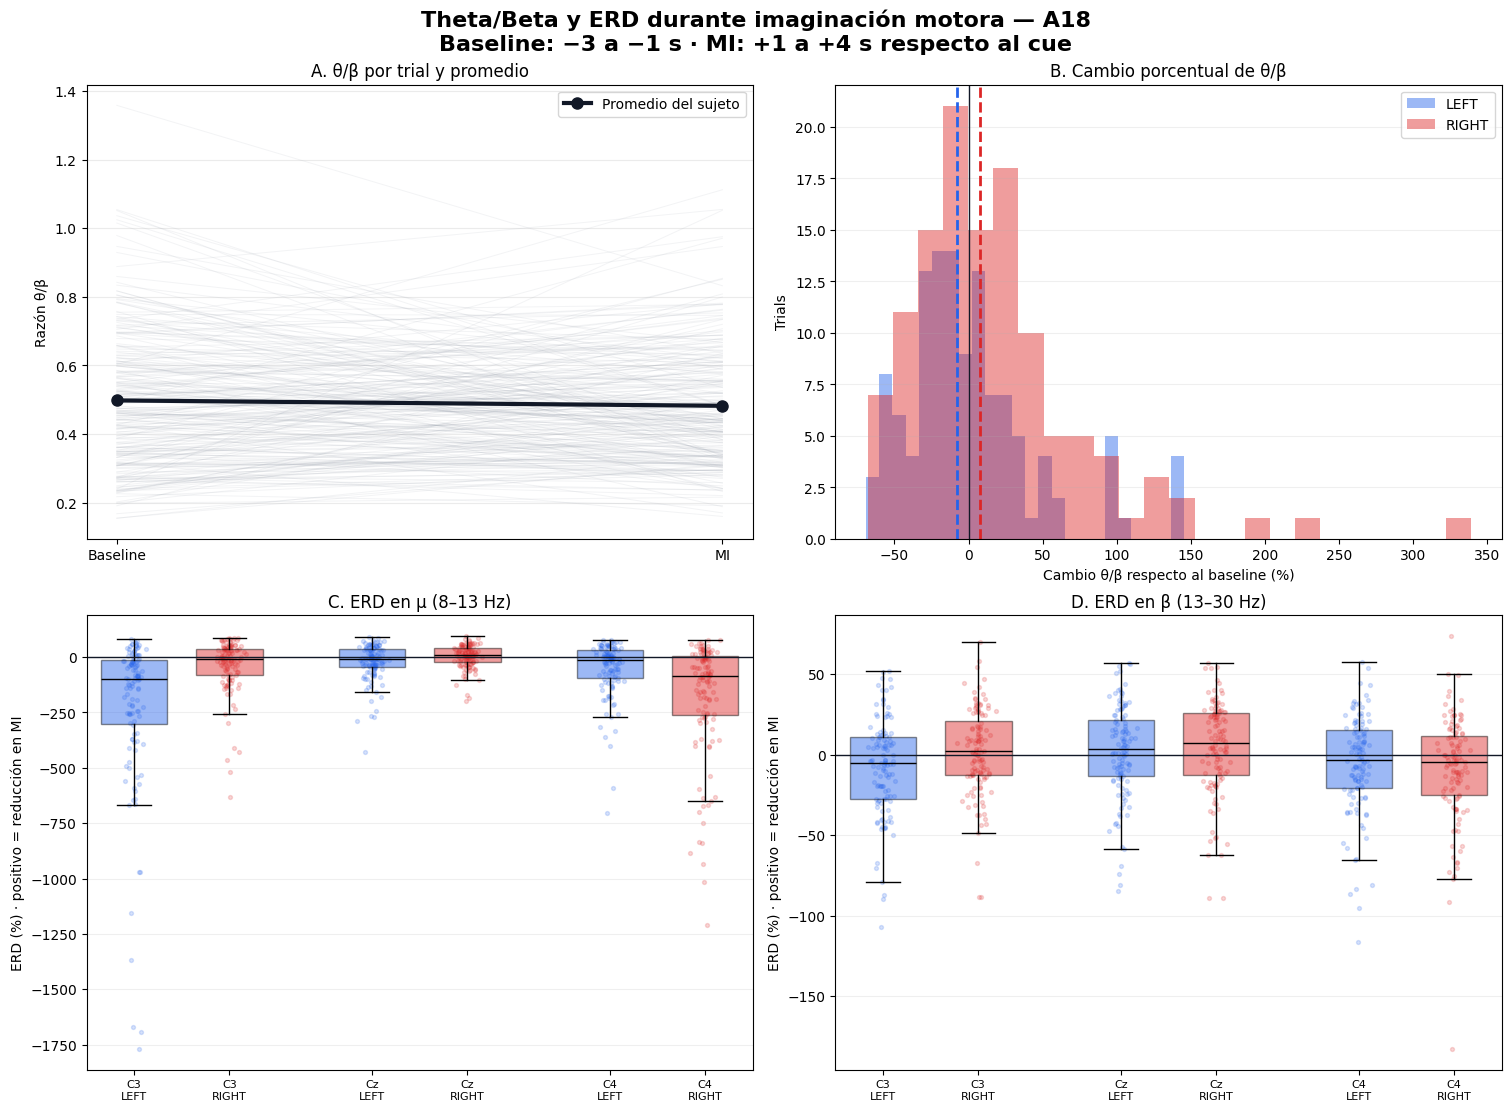

In [12]:
summary_figure = create_summary_figure(valid_trials, valid_channels, SUBJECT)
plt.show()

## 13. Guardar evidencia reproducible

Se guardan las filas por canal, el resumen por trial, la figura y un JSON con todos los parámetros y estadísticas. Estos archivos permiten auditar el resultado sin repetir el procesamiento.

In [13]:
def save_results(subject: str, output_root: Path, channels: pd.DataFrame,
                 trials: pd.DataFrame, metadata: dict, include_artifacts: bool):
    output_dir = output_root / subject
    output_dir.mkdir(parents=True, exist_ok=True)
    all_trial_count = len(trials)
    artifact_count = int(trials.artifact.sum())
    valid_channels = channels if include_artifacts else channels.loc[~channels.artifact].copy()
    valid_trials = trials if include_artifacts else trials.loc[~trials.artifact].copy()
    if valid_trials.empty:
        raise RuntimeError("Todos los trials fueron rechazados por artefactos.")

    channel_path = output_dir / "theta_beta_erd_por_canal.csv"
    trial_path = output_dir / "theta_beta_erd_por_trial.csv"
    figure_path = output_dir / "resumen_theta_beta_erd.png"
    report_path = output_dir / "resumen.json"
    channels.to_csv(channel_path, index=False)
    trials.to_csv(trial_path, index=False)

    figure = create_summary_figure(valid_trials, valid_channels, subject)
    figure.savefig(figure_path, dpi=180, bbox_inches="tight")

    report = {
        "subject": subject,
        "channels": list(CHANNELS),
        "classes": valid_trials["class"].value_counts().to_dict(),
        "sampling_rate_hz": 512.0,
        "baseline_seconds_relative_to_cue": list(BASELINE_SECONDS),
        "mi_seconds_relative_to_cue": list(MI_SECONDS),
        "bands_hz": {name: list(limits) for name, limits in BANDS.items()},
        "welch": {"nperseg_seconds": 1.0, "overlap": 0.5, "window": "hann"},
        "preprocessing": {
            "notch_hz": LINE_FREQUENCY_HZ,
            "bandpass_hz": list(FILTER_BAND_HZ),
            "reference": "average EEG reference before selecting C3/Cz/C4",
            "artifact_threshold_uv": ARTIFACT_THRESHOLD_UV,
        },
        "erd_formula": "100 * (power_baseline - power_mi) / power_baseline",
        "artifact_trials": artifact_count,
        "trials_total": all_trial_count,
        "trials_analyzed": int(len(valid_trials)),
        "artifacts_included_in_statistics": include_artifacts,
        "source": metadata,
        "overall": paired_statistics(valid_trials),
        "by_class": {
            class_name: paired_statistics(group)
            for class_name, group in valid_trials.groupby("class")
        },
    }
    report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")
    return output_dir, report, figure

In [14]:
output_dir, report, saved_figure = save_results(
    SUBJECT,
    OUTPUT_ROOT,
    channel_results,
    trial_results,
    source_metadata,
    include_artifacts=False,
)
plt.close(saved_figure)

print("Resultados guardados en:", output_dir)
for path in sorted(output_dir.iterdir()):
    print(f"  {path.name}: {path.stat().st_size:,} bytes")

Resultados guardados en: D:\Proyects\Python\BCI_workspace\BCI_Neurofeedback\results\A18
  resumen.json: 3,206 bytes
  resumen_theta_beta_erd.png: 699,893 bytes
  theta_beta_erd_por_canal.csv: 205,630 bytes
  theta_beta_erd_por_trial.csv: 68,031 bytes


## 14. Interpretación del resultado obtenido

Para A18 se analizaron **240/240 trials** y no se rechazó ninguno por amplitud.

| Resultado global | Valor |
|---|---:|
| Theta/Beta promedio en baseline | 0.4979 |
| Theta/Beta promedio en MI | 0.4822 |
| Cambio mediano por trial | −1.43 % |
| Wilcoxon global | p = 0.4925 |
| ERD μ mediano | −23.70 % |
| ERD beta mediano | +0.97 % |

La reducción aproximada del 3.15 % entre los dos promedios no fue consistente trial por trial. El valor `p = 0.4925` no aporta evidencia de una diferencia global entre baseline y MI.

Al separar las clases apareció una tendencia distinta:

- **LEFT:** cambio mediano Theta/Beta de −8.04 %, `p = 0.0284`.
- **RIGHT:** cambio mediano de +7.68 %, `p = 0.2691`.

LEFT debe considerarse exploratorio, no una confirmación definitiva, porque se examinaron múltiples clases, canales y sesiones.

El ERD μ negativo indica que, con la convención utilizada, predominó un aumento de potencia en MI en lugar de la reducción esperada. Beta presentó una reducción mediana muy pequeña. La dispersión muestra que la respuesta no fue uniforme.

## 15. Conclusión

El análisis confirma que el pipeline puede leer los GDF continuos, reconstruir baseline y MI, estimar PSD y calcular Theta/Beta y ERD de manera reproducible. Sin embargo, **A18 no mostró un cambio global consistente de Theta/Beta ni un ERD uniforme** con esta configuración.

Esto no implica que el código está fallando. El dataset fue creado para clasificar imaginación motora LEFT/RIGHT, no para entrenar atención mediante neurofeedback. CSP puede aprovechar diferencias espaciales entre C3 y C4 aunque el promedio global de Theta/Beta sea pequeño. Además, las sesiones `onlineT` incluyen feedback del protocolo original y pueden diferir de las sesiones de adquisición.

Por tanto, este experimento funciona como validación técnica y análisis exploratorio. La validación de un índice de atención necesitará un nuevo protocolo con baseline estable, tareas atencionales, feedback continuo y una medida externa de desempeño.